# Semana 4: Mapas polinomiales, complejidad y leakage

**Pregunta de trabajo.** Comparar grados con train/dev y mantener dentro de la tubería todo paso aprendido.

In [1]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
rng = np.random.default_rng(2105)
x = np.linspace(-3, 3, 120)
y = np.sin(x) + rng.normal(0, 0.25, size=x.shape)
X = x.reshape(-1, 1)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.35, random_state=2105)

In [3]:
for degree in [1, 3, 12]:
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    print(degree, mean_squared_error(y_train, model.predict(X_train)), mean_squared_error(y_val, model.predict(X_val)))

1 0.23070835857233446 0.27417760667946733
3 0.06171177306775757 0.07937556396281385
12 0.05359725463869724 0.08551352705714263


## Tabla de complejidad y estabilidad

Todos los candidatos usan los mismos índices. La transformación polinomial vive dentro de la tubería.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

records = []
models = {}
for degree in [1, 2, 3, 5, 12]:
    candidate = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
    candidate.fit(X_train, y_train)
    records.append({
        "grado": degree,
        "mse_train": mean_squared_error(y_train, candidate.predict(X_train)),
        "mse_dev": mean_squared_error(y_val, candidate.predict(X_val)),
        "columnas": candidate.named_steps["polynomialfeatures"].n_output_features_,
    })
    models[degree] = candidate
results = pd.DataFrame(records)
results

,grado,mse_train,mse_dev,columnas
0,1,0.230708,0.274178,1
1,2,0.225855,0.283868,2
2,3,0.061712,0.079376,3
3,5,0.058204,0.074000,5
4,12,0.053597,0.085514,12


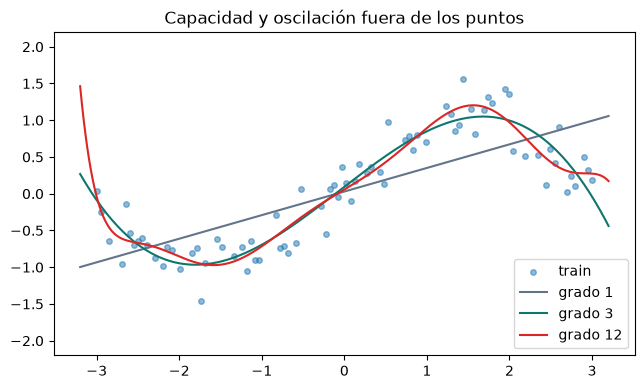

In [5]:
grid = np.linspace(-3.2, 3.2, 300).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(X_train[:, 0], y_train, s=16, alpha=0.5, label="train")
for degree, color in [(1, "#64748b"), (3, "#0f766e"), (12, "#dc2626")]:
    ax.plot(grid[:, 0], models[degree].predict(grid), color=color, label=f"grado {degree}")
ax.set_ylim(-2.2, 2.2)
ax.legend()
ax.set_title("Capacidad y oscilación fuera de los puntos")
plt.show()

In [6]:
best_degree = int(results.loc[results["mse_dev"].idxmin(), "grado"])
best_degree, models[best_degree].named_steps["polynomialfeatures"].get_feature_names_out()

(5, array(['x0', 'x0^2', 'x0^3', 'x0^4', 'x0^5'], dtype=object))

In [7]:
split_rows = []
for seed in [2105, 2106, 2107, 2108, 2109]:
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.35, random_state=seed)
    for degree in [3, 12]:
        candidate = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
        candidate.fit(Xa, ya)
        split_rows.append({"semilla": seed, "grado": degree, "mse_dev": mean_squared_error(yb, candidate.predict(Xb))})
pd.DataFrame(split_rows).groupby("grado")["mse_dev"].agg(["mean", "std", "min", "max"])

,mean,std,min,max
grado,,,,
3,0.081181,0.009787,0.071268,0.097414
12,0.089487,0.017622,0.072925,0.117845


In [8]:
assert set(results["grado"]) == {1, 2, 3, 5, 12}
print(f"Grado seleccionado en la partición principal: {best_degree}. Test sigue reservado.")

Grado seleccionado en la partición principal: 5. Test sigue reservado.
